# 03 — Model Training & Evaluation

Train 4 models, Bootstrap Learning Curves, so sánh kết quả.

**Thứ tự chạy:** 01_eda → 02_processing → **03_modeling**

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from src.model_trainer import ModelTrainer

## 1. Load Processed Data

Load 6 file `.npy` đã lưu ở notebook 02 — train / val / test.

| File | Vai trò |
|------|---------|
| `X_train`, `y_train` | Dạy model |
| `X_val`, `y_val` | Tune, early stopping, chọn model |
| `X_test`, `y_test` | Đánh giá cuối cùng — chỉ dùng 1 lần |


In [2]:
X_train = np.load('../data/X_train.npy')
X_val   = np.load('../data/X_val.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_val   = np.load('../data/y_val.npy')
y_test  = np.load('../data/y_test.npy')

target_classes = ['Abnormal', 'Inconclusive', 'Normal']

n = len(X_train) + len(X_val) + len(X_test)
print(f'X_train : {X_train.shape}  ({len(X_train)/n*100:.0f}%)')
print(f'X_val   : {X_val.shape}   ({len(X_val)/n*100:.0f}%)')
print(f'X_test  : {X_test.shape}   ({len(X_test)/n*100:.0f}%)')


X_train : (44400, 12)  (80%)
X_val   : (5550, 12)   (10%)
X_test  : (5550, 12)   (10%)


## 2. Train 4 Models + Bootstrap Learning Curves

`ModelTrainer` train 4 models cùng lúc. Bootstrap curves dùng `X_val`
để đo performance tại mỗi epoch → thấy model hội tụ như thế nào.

In [3]:
trainer = ModelTrainer()
trainer.fit(
    X_train, y_train,
    X_test,  y_test,
    X_val=X_val, y_val=y_val,  # dùng val để track learning curve
    run_bootstrap = True,
    n_points      = 12,
    n_iters       = 3,
    run_cv        = True
)


Train: (44400, 12) | Val: (5550, 12) | Test: (5550, 12)

Training Logistic Regression... test_acc=0.3321  val_acc=0.3274  f1=0.3271  cv=0.3324±0.0040  (4.9s)
Training Decision Tree... test_acc=0.3310  val_acc=0.3514  f1=0.3196  cv=0.3386±0.0035  (9.4s)
Training Random Forest... test_acc=0.3721  val_acc=0.3899  f1=0.3717  cv=0.3754±0.0053  (98.8s)
Training Gradient Boosting... test_acc=0.3389  val_acc=0.3550  f1=0.3383  cv=0.3473±0.0065  (668.9s)

🏆 Best: Random Forest (test_acc=0.3721)


## 3. Kết quả tổng hợp

In [4]:
trainer.summary()

                     Test Acc  Test F1  Val Acc  Val F1  CV Mean  CV Std  Time (s)
Model                                                                             
Random Forest          0.3721   0.3717   0.3899  0.3893   0.3754  0.0053      44.7
Gradient Boosting      0.3389   0.3383   0.3550  0.3543   0.3473  0.0065     301.7
Logistic Regression    0.3321   0.3271   0.3274  0.3225   0.3324  0.0040       4.6
Decision Tree          0.3310   0.3196   0.3514  0.3418   0.3386  0.0035       6.9


,Test Acc,Test F1,Val Acc,Val F1,CV Mean,CV Std,Time (s)
Model,,,,,,,
Random Forest,0.3721,0.3717,0.3899,0.3893,0.3754,0.0053,44.7
Gradient Boosting,0.3389,0.3383,0.3550,0.3543,0.3473,0.0065,301.7
Logistic Regression,0.3321,0.3271,0.3274,0.3225,0.3324,0.0040,4.6
Decision Tree,0.3310,0.3196,0.3514,0.3418,0.3386,0.0035,6.9


## 4. Bootstrap Learning Curves

**Đọc biểu đồ:**
- Trục X = % training data đã dùng (= 'epoch')
- Đường = accuracy/F1 trung bình qua 3 bootstrap runs
- Vùng bóng = mean ± std → hẹp = model ổn định, rộng = high variance
- Đường đỏ đứt = random baseline 33.3%

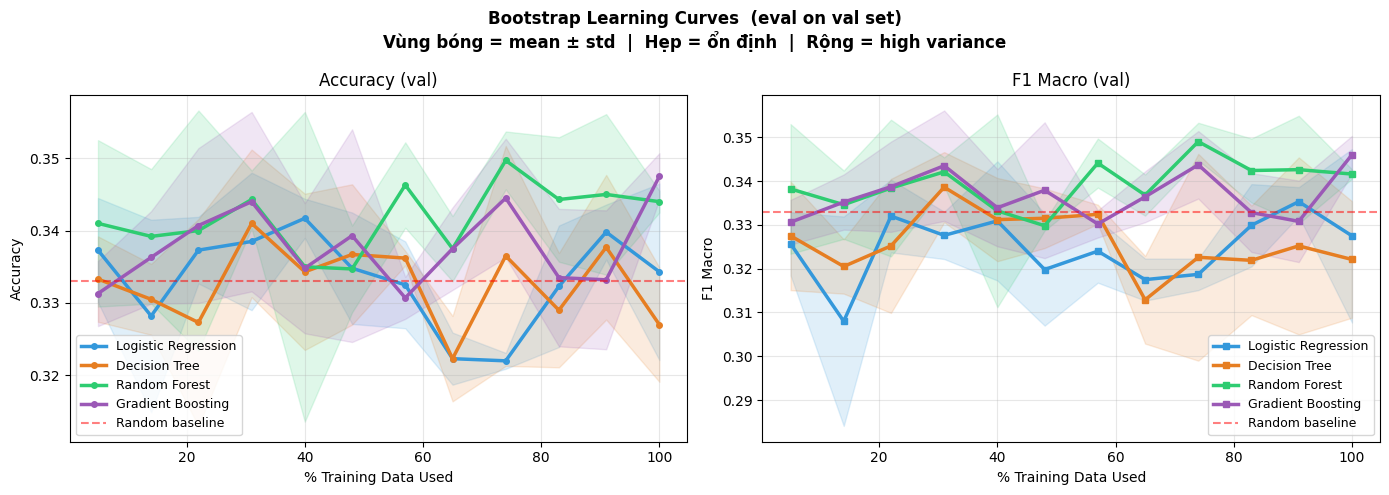

In [5]:
trainer.plot_bootstrap_curves()

## 5. So sánh Models

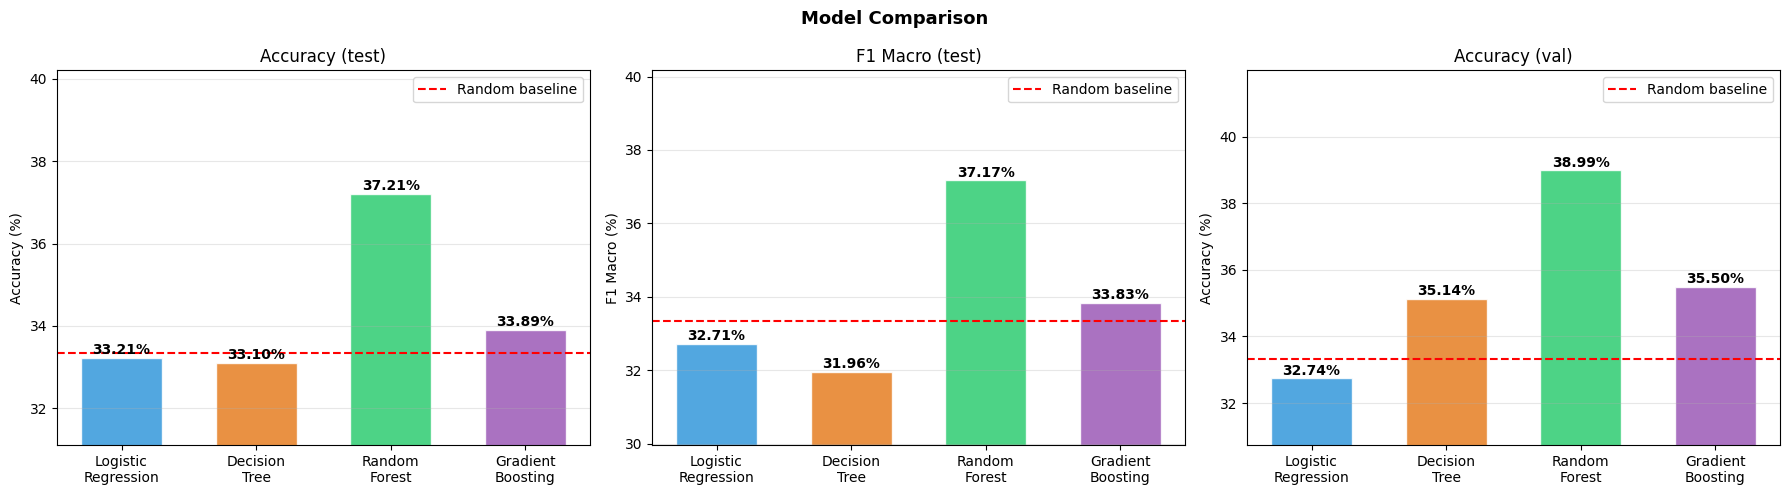

In [6]:
trainer.plot_comparison()

## 6. Confusion Matrices

**Đọc confusion matrix:**
- Diagonal (trái trên → phải dưới) = dự đoán **ĐÚNG**
- Off-diagonal = dự đoán **SAI** (model nhầm class nào sang class nào)

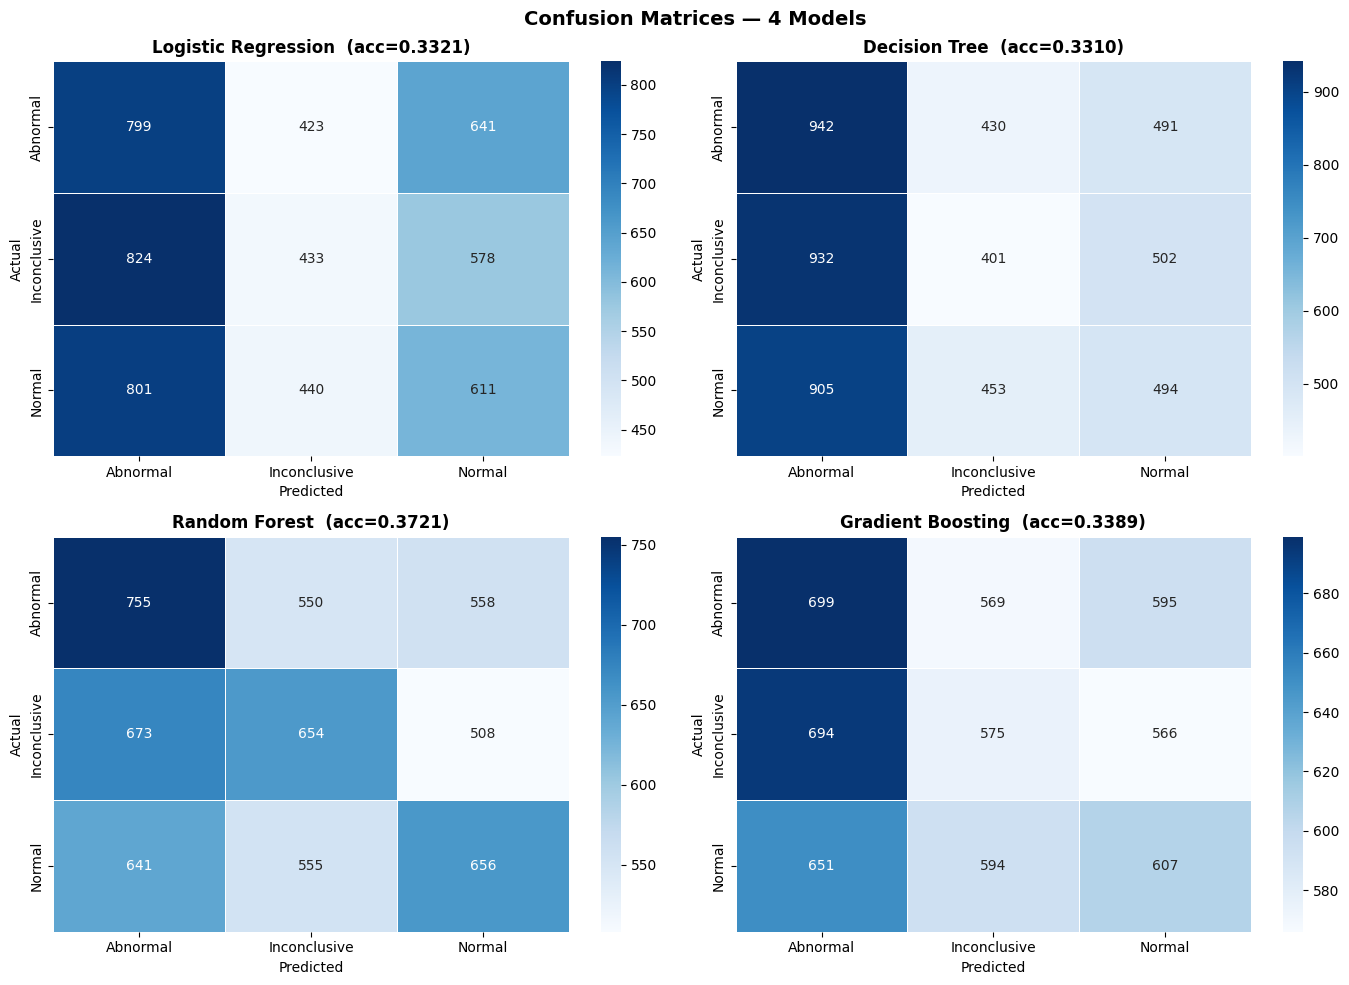

In [7]:
# Vẽ confusion matrix cho từng model
n = len(trainer.results)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — 4 Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, res) in enumerate(trainer.results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=target_classes, yticklabels=target_classes,
                linewidths=0.5)
    axes[i].set_title(f'{name}  (acc={res["accuracy"]:.4f})', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 7. Classification Report — Best Model

**Metrics:**
- `Precision`: trong số dự đoán là X, bao nhiêu % thực sự là X?
- `Recall`: trong số thực sự là X, model tìm được bao nhiêu %?
- `F1-score`: trung bình điều hòa của Precision và Recall
- `Support`: số mẫu thực tế thuộc class đó trong test set

In [8]:
best = trainer.best_name
print(f'Best model: {best}\n')
print(classification_report(
    y_test,
    trainer.results[best]['y_pred'],
    target_names=target_classes,
    digits=4
))

Best model: Random Forest

              precision    recall  f1-score   support

    Abnormal     0.3649    0.4053    0.3840      1863
Inconclusive     0.3718    0.3564    0.3639      1835
      Normal     0.3810    0.3542    0.3671      1852

    accuracy                         0.3721      5550
   macro avg     0.3726    0.3720    0.3717      5550
weighted avg     0.3725    0.3721    0.3717      5550



## 8. Feature Importance (Random Forest)

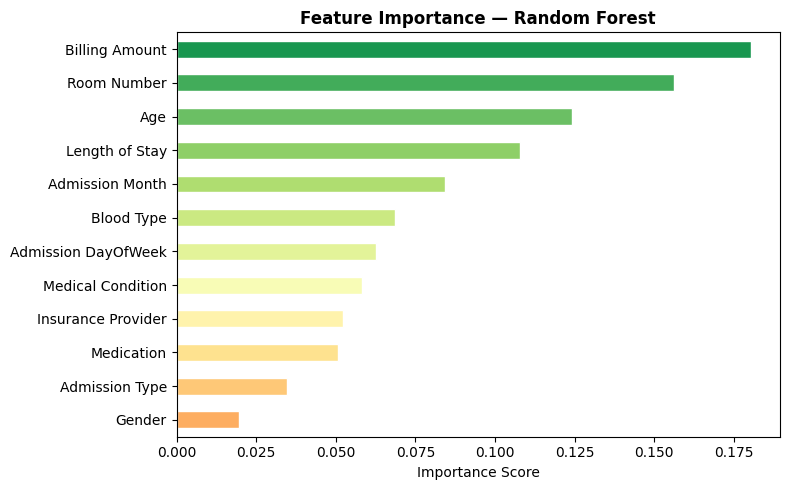


Top features:
Billing Amount         0.180500
Room Number            0.156341
Age                    0.124344
Length of Stay         0.107851
Admission Month        0.084337
Blood Type             0.068595
Admission DayOfWeek    0.062776
Medical Condition      0.058130
Insurance Provider     0.052343
Medication             0.050626
Admission Type         0.034527
Gender                 0.019630


In [9]:
rf = trainer.get_model('Random Forest')

feature_names = [
    'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider',
    'Billing Amount', 'Room Number', 'Admission Type', 'Medication',
    'Length of Stay', 'Admission Month', 'Admission DayOfWeek'
]

fi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi)))
fi.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop features:')
print(fi.sort_values(ascending=False).to_string())

## 9. Lưu Model

In [10]:
import os
os.makedirs('../models', exist_ok=True)

best_model = trainer.get_best_model()
joblib.dump(best_model, f'../models/best_model_{trainer.best_name.lower().replace(" ","_")}.pkl')

for name, res in trainer.results.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(res['model'], f'../models/{fname}.pkl')

print(f'✅ Saved all models to models/')
print(f'   Best: {trainer.best_name} (acc={trainer.results[trainer.best_name]["accuracy"]:.4f})')

✅ Saved all models to models/
   Best: Random Forest (acc=0.3721)
